In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import warnings
import statsmodels as sm
import yfinance as yf
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
end = dt.date.today()
start = end - dt.timedelta(days=365*5)
df = yf.download('RELIANCE.NS', start, end,auto_adjust=True)
df.columns = df.columns.droplevel(1)
df.columns = df.columns.str.lower()
df = df.drop(columns=['high','low','open','volume'])
df.index = pd.to_datetime(df.index)

[*********************100%***********************]  1 of 1 completed


In [3]:
df1 = df.copy()

# Moving Average Crossover

Buy and Hold Returns =  0.5387526363200432
Crossover Strategy Returns = 0.10198052361287924
Total Entries: 131
Total Exits: 131


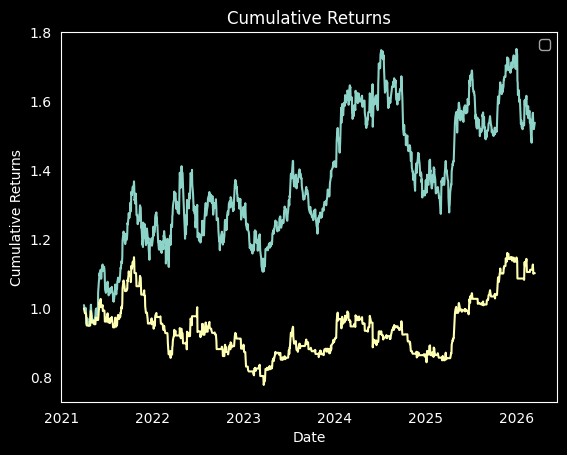

In [5]:
# Yesterday Price
df['yesterday_price'] = df['close'].shift(1)

# Returns
df['pct_change'] = df['close']/df['yesterday_price']-1

# Moving Averages
s_ma = 3
l_ma = 5
df['20sma'] = df['close'].rolling(s_ma).mean()
df['50lma'] = df['close'].rolling(l_ma).mean()

#
df['signal'] = np.where(df['20sma'] > df['50lma'], 1, 0)
df['position'] = df['signal'].shift(1)
df = df.dropna()
df['strategy_return'] = df['pct_change'] * df['position']
df['growth'] = 1 + df['strategy_return']
df['strategy_cum_growth'] = df['growth'].cumprod()
df['buyhold'] = df['pct_change'] + 1
df['buyhold_cum_growth'] = df['buyhold'].cumprod()
buy_and_hold = df['buyhold_cum_growth'][-1] -1
strategy_return = df['strategy_cum_growth'][-1] -1
print("Buy and Hold Returns = ", buy_and_hold)
print("Crossover Strategy Returns =",strategy_return)

df['trade'] = df['position'].diff()

entries = (df['trade'] == 1).sum()
exits = (df['trade'] == -1).sum()

print("Total Entries:", entries)
print("Total Exits:", exits)


plt.plot(df[['buyhold_cum_growth','strategy_cum_growth']])
plt.title('Cumulative Returns')
plt.ylabel('Cumulative Returns')
plt.xlabel('Date')
plt.legend()
plt.grid()
plt.show()

# Rsi Strategy

In [9]:
dfa = df1.copy()

In [10]:
dfa['yesterday_price'] = dfa['close'].shift(1)
dfa['change'] = dfa['close'] - dfa['yesterday_price']
dfa['gain'] = dfa['change'].apply(lambda x: x if x > 0 else 0)
dfa['loss'] = dfa['change'].apply(lambda x: x if x < 0 else 0)
dfa['loss'] = dfa['loss'] * -1
dfa['avg_gain'] = dfa['gain'].rolling(14).mean()
dfa['avg_loss'] = dfa['loss'].rolling(14).mean()
dfa.dropna(inplace=True)
dfa['rs'] = dfa['avg_gain'] / dfa['avg_loss']
dfa['rsi'] = 100 - (100 / (1 + dfa['rs']))
dfa['buy_signal'] = (dfa['rsi'].apply(lambda x : 1 if x < 30   else 0))
dfa['sell_signal'] = (dfa['rsi'].apply(lambda x : 1 if x > 70  else 0))
dfa['position'] = 0
dfa['current_position'] = 0

In [11]:
dfa

Price,close,yesterday_price,change,gain,loss,avg_gain,avg_loss,rs,rsi,buy_signal,sell_signal,position,current_position
Date,,,,,,,,,,,,,
2021-04-09,898.723450,909.288330,-10.564880,0.000000,10.564880,3.327859,6.565029,0.506907,33.638905,0,0,0,0
2021-04-12,866.575134,898.723450,-32.148315,0.000000,32.148315,3.327859,8.861337,0.375548,27.301711,1,0,0,0
2021-04-13,875.938538,866.575134,9.363403,9.363403,-0.000000,3.996674,8.226536,0.485827,32.697414,0,0,0,0
2021-04-15,881.606384,875.938538,5.667847,5.667847,-0.000000,3.588575,8.226536,0.436219,30.372757,0,0,0,0
2021-04-16,876.074463,881.606384,-5.531921,0.000000,5.531921,3.588575,7.319672,0.490264,32.897817,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-11,1390.199951,1408.800049,-18.600098,0.000000,18.600098,7.614293,11.264300,0.675967,40.332947,0,0,0,0
2026-03-12,1392.199951,1390.199951,2.000000,2.000000,-0.000000,7.757150,8.992868,0.862589,46.311294,0,0,0,0
2026-03-13,1380.699951,1392.199951,-11.500000,0.000000,11.500000,7.050005,9.814296,0.718340,41.804312,0,0,0,0
